# Assignment Sesi 16
Nama: Faraday Barr Fatahillah

Instruksi\
Anda adalah data scientist di perusahaan telekomunikasi. Tim produk ingin memahami faktor-faktor yang membuat pelanggan berhenti berlangganan (churn). Sebelum membangun model klasifikasi yang lebih canggih, Anda diminta menyiapkan pipeline feature engineering yang bersih dan terukur dampaknya terhadap performa model dasar.

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler

**Task 1 — Persiapan Data dan Baseline Model**
1. Load dataset dan tampilkan shape serta tipe data tiap kolom.
2. Drop kolom customerID karena tidak informatif untuk model.
3. Ubah kolom TotalCharges ke tipe numerik dengan pd.to_numeric dan parameter errors='coerce'. Drop baris yang menjadi NaN.
4. Encode kolom target Churn: Yes = 1, No = 0.
5. Pisahkan fitur numerik dari fitur kategorikal. Tampilkan daftar nama kolom masing-masing.
6. Untuk baseline: gunakan HANYA fitur numerik (tenure, MonthlyCharges, TotalCharges) sebagai X. Target y = Churn.
7. Latih LogisticRegression (max_iter=1000) dengan 5-fold cross validation menggunakan cross_val_score dengan scoring='accuracy'. Cetak rata-rata skor CV dan standar deviasinya.

In [2]:
#Task 1.1
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
#Task 1.2
df = df.drop(columns=['customerID'])

df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
#Task 1.3
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [7]:
df.isna().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [8]:
df = df.dropna(subset=['TotalCharges'])

In [9]:
df.isna().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [11]:
df['Churn'].dtype

dtype('int64')

In [12]:
numerik = ['tenure','MonthlyCharges','TotalCharges']
kategorik = df.drop(columns=numerik + ['Churn']).columns.tolist() 

print(numerik)
print(kategorik)

['tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:
X = df[numerik]
y = df['Churn']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print('Baseline:')
print("CV Accuracy per fold:", scores)
print("Mean CV Accuracy:", scores.mean())
print("Std CV Accuracy :", scores.std())


Baseline:
CV Accuracy per fold: [0.78393746 0.78678038 0.77240398 0.78947368 0.79302987]
Mean CV Accuracy: 0.7851250756985243
Std CV Accuracy : 0.007033816714408396


**Task 2 — Feature Scaling dan Dampaknya**
1. Buat histogram untuk kolom tenure, MonthlyCharges, dan TotalCharges dalam satu figure dengan subplot 1x3.
2. Berdasarkan distribusi yang terlihat, pilih satu teknik scaling yang paling sesuai (MinMaxScaler, StandardScaler, atau RobustScaler) dan tuliskan alasannya di cell markdown (2 sampai 3 kalimat).
3. Terapkan scaler yang Anda pilih pada ketiga kolom numerik. PENTING: fit scaler hanya pada training set, lalu transform keduanya. Gunakan split 80:20, random_state=42.
4. Latih LogisticRegression pada data yang sudah di-scale dengan 5-fold CV. Cetak skor rata-rata dan standar deviasinya.
5. Bandingkan skor CV baseline (Task 1) vs setelah scaling. Apakah ada perubahan? Tulis 2 kalimat interpretasi.

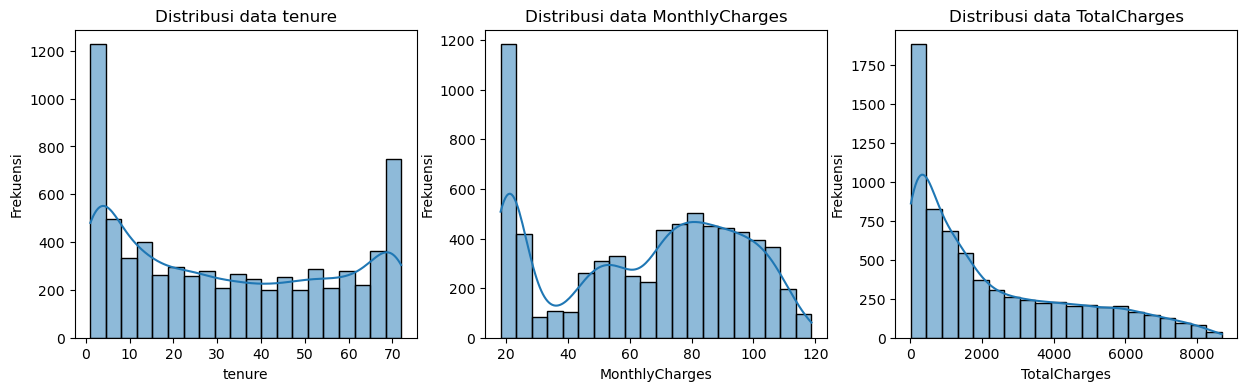

In [15]:
#Task 2.1
plt.figure(figsize=(15,4))

for i, col in enumerate(numerik, 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df[col], bins=20, kde=True)
    plt.title(f'Distribusi data {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.show()

**#Task 2.2**\
Setelah melihat hasil distribusi ketiga data numerik, dapat dilihat pada grafik di atas bahwa semua data menunjukkan skewness dan memiliki potensi outlier. Hal yang perlu di fokuskan adalah distribusi data TotalCharges yang sangat skew ke kanan. Maka dari itu, perlu menggunakan RobustScaler yang menggunakan median dan IQR sehingga tidak terlalu terpengaruh dari nilai ekstrim.

In [16]:
#Task 2.3

X_baru = df[numerik]
y_baru = df['Churn']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 0.30434783, -0.38939671,  0.20418941],
       [-0.56521739, -0.30987203, -0.35583314],
       [ 0.56521739,  0.13528336,  0.91091562],
       ...,
       [-0.43478261,  0.19744059, -0.1790737 ],
       [ 0.45652174, -0.9250457 , -0.11836874],
       [-0.19565217,  0.06032907,  0.0224009 ]], shape=(5625, 3))

In [17]:
#Task 2.4
model_scaled = LogisticRegression(max_iter=1000)

cv_scores_scaled = cross_val_score(model_scaled,X_train_scaled,y_train,cv=5,scoring='accuracy')

print("Scaling")
print("CV Accuracy (scaled):", cv_scores_scaled)
print("Mean CV Accuracy:", cv_scores_scaled.mean())
print("Std CV Accuracy :", cv_scores_scaled.std())


Scaling
CV Accuracy (scaled): [0.78044444 0.78666667 0.79466667 0.77511111 0.79644444]
Mean CV Accuracy: 0.7866666666666666
Std CV Accuracy : 0.008146801235477032


**#Task 2.5**\
Baseline skor CV yang didapatkan sebelumnya adalah 0.78 dan setelah scaling menggunakan RobustScaler tetap sama di 0.78 sehingga tidak terdapat perubahan yang signifikan. Hal ini karena logistic regression yang digunakan hanya menggunakan 3 fitur numerik sehingga dampaknya terlalu kecil.

**Task 3 — Encoding Fitur Kategorikal**
1. Dari kolom kategorikal, identifikasi mana yang bersifat ORDINAL (punya urutan natural) dan mana yang NOMINAL. Tulis daftar keduanya di cell markdown.
2. Terapkan Ordinal Encoding pada kolom Contract dengan urutan: Month-to-month = 0, One year = 1, Two year = 2.
3. Terapkan One-Hot Encoding pada kolom InternetService dan PaymentMethod menggunakan pd.get_dummies dengan drop_first=True.
4. Untuk sisa kolom binary kategorikal (gender, Partner, Dependents, PhoneService): terapkan encoding manual dengan map.
5. Gabungkan seluruh fitur (numerik yang sudah di-scale + kategorikal yang sudah di-encode) menjadi satu dataframe X_final. Latih LogisticRegression dengan 5-fold CV dan cetak hasilnya.

**#Task 3.1**\
Data Ordinal:
1. Contract


Data Nominal:
1. InternetService
2. PaymentMethod
4. gender
5. Partner
6. Dependent
7. PhoneService


In [18]:
#Task 3.2
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

df['Contract_encoded'] = df['Contract'].map(contract_map)

df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_encoded
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,1
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,1
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0


In [19]:
#Task 3.3
df_onehot = pd.get_dummies(df[['InternetService', 'PaymentMethod']],drop_first=True)

df_onehot


,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,False,False,False,True,False
1,False,False,False,False,True
2,False,False,False,False,True
3,False,False,False,False,False
4,True,False,False,True,False
...,...,...,...,...,...
7038,False,False,False,False,True
7039,True,False,True,False,False
7040,False,False,False,True,False
7041,True,False,False,False,True


In [20]:
#Task 3.4
mapping_binary = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
} 

bin_col = ['gender', 'Partner', 'Dependents', 'PhoneService']

for col in bin_col:
    df[col + '_encoded'] = df[col].map(mapping_binary)

df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_encoded,gender_encoded,Partner_encoded,Dependents_encoded,PhoneService_encoded
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,0,0,0,1,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,0,1,1,0,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,0,1,0,0,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,0,1,1,0,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Mailed check,84.80,1990.50,0,1,1,1,1,1
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Credit card (automatic),103.20,7362.90,0,1,0,1,1,1
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,Yes,Electronic check,29.60,346.45,0,0,0,1,1,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,Mailed check,74.40,306.60,1,0,1,1,0,1


In [21]:
#Task 3.5
X_cat = pd.concat([df[['Contract_encoded']], df_onehot, df[[col + '_encoded' for col in bin_col]]], axis=1)

X_cat_train = X_cat.loc[X_train.index]
X_cat_test  = X_cat.loc[X_test.index]

In [22]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=['tenure', 'MonthlyCharges', 'TotalCharges'], index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=['tenure', 'MonthlyCharges', 'TotalCharges'], index=X_test.index)


In [23]:
X_final_train = pd.concat([X_train_scaled, X_cat_train], axis=1)
X_final_test  = pd.concat([X_test_scaled, X_cat_test], axis=1)

In [24]:
model_final = LogisticRegression(max_iter=1000)

cv_scores_final = cross_val_score(model_final, X_final_train, y_train, cv=5, scoring='accuracy')

print('Scaling + Encoding')
print("CV Accuracy scores:", cv_scores_final)
print("Mean CV Accuracy:", cv_scores_final.mean())
print("Std CV Accuracy :", cv_scores_final.std())


Scaling + Encoding
CV Accuracy scores: [0.80177778 0.80177778 0.79022222 0.78755556 0.81333333]
Mean CV Accuracy: 0.7989333333333334
Std CV Accuracy : 0.009261522686315452


**Task 4 — Feature Selection Berbasis Korelasi**
1. Hitung korelasi Pearson antara setiap fitur numerik di X_final dengan kolom target y. Tampilkan hasilnya sebagai bar chart horizontal yang diurutkan dari korelasi tertinggi ke terendah, dengan warna berbeda untuk korelasi positif dan negatif.
2. Pilih fitur-fitur dengan nilai absolut korelasi di atas 0.10 sebagai fitur terpilih. Tampilkan daftar nama fitur tersebut.
3. Latih LogisticRegression dengan 5-fold CV menggunakan hanya fitur terpilih. Cetak skor rata-rata dan standar deviasinya.
4. Buat tabel ringkasan performa di cell markdown yang membandingkan keempat eksperimen: Baseline, Setelah scaling, Setelah scaling + encoding, Setelah feature selection.
5. Tulis 3 sampai 4 kalimat kesimpulan: teknik mana yang paling berdampak pada skor CV, dan mengapa menurut Anda demikian?

In [25]:
#Task 4.1
corr_df = X_final_train.copy()
corr_df['Churn'] = y_train

corr_values = corr_df.corr()['Churn'].drop('Churn')

corr_values_sorted = corr_values.reindex(corr_values.abs().sort_values(ascending=False).index)


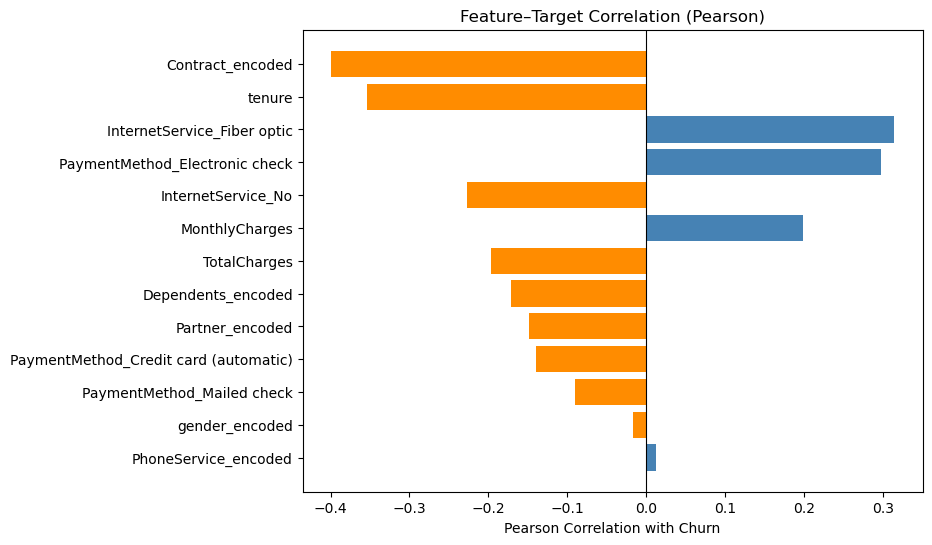

In [26]:
colors = ['steelblue' if v > 0 else 'darkorange' for v in corr_values_sorted]

plt.figure(figsize=(8, 6))
plt.barh(corr_values_sorted.index, corr_values_sorted.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Pearson Correlation with Churn")
plt.title("Feature–Target Correlation (Pearson)")
plt.gca().invert_yaxis()
plt.show()


In [27]:
#Task 4.2
selected_features = corr_values_sorted[corr_values_sorted.abs() > 0.10].index.tolist()

print("Fitur Terpilih (|corr| > 0.10):")
print(selected_features)


Fitur Terpilih (|corr| > 0.10):
['Contract_encoded', 'tenure', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'InternetService_No', 'MonthlyCharges', 'TotalCharges', 'Dependents_encoded', 'Partner_encoded', 'PaymentMethod_Credit card (automatic)']


In [28]:
#Task 4.3
X_selected_train = X_final_train[selected_features]

model_selected = LogisticRegression(max_iter=1000)

cv_scores_selected = cross_val_score(model_selected, X_selected_train, y_train, cv=5, scoring='accuracy')

print('Feature Selection')
print("CV Accuracy (Feature Selection):", cv_scores_selected)
print("Mean CV Accuracy:", cv_scores_selected.mean())
print("Std  CV Accuracy:", cv_scores_selected.std())


Feature Selection
CV Accuracy (Feature Selection): [0.79733333 0.79466667 0.79377778 0.78844444 0.81511111]
Mean CV Accuracy: 0.7978666666666667
Std  CV Accuracy: 0.009092772872920492


**#Task 4.4**
| Metrik | Baseline | Scaling | Scaling + Encoding | Feature Selection |
|--------|----------|---------|--------------------|-------------------|
| Mean    | 0.785 | 0.786 | 0.798 | 0.797 |
| Standar Deviasi | 0.007 | 0.008 | 0.009 | 0.009

**#Task 4.5**\
Kesimpulan:\
Penambahan scaling dengan encoding memberikan dampak paling signifikan antara skor cross-validation, karena informasi yang digunakan sangat relevan dengan keputusan churn pelanggan. Feature selection berbasis korelasi tidak memberikan penurunan performa walaupun beberapa fitur berkurang karena yang menunjukkan korelasi rendah memang tidak banyak. Hanya melakukan scaling juga tidak memberikan dampak yang besar karena model sudah stabil dalam numerik yang ada. Secara keseluruhan, pipeline encoding ditambah scaling menghasilkan representasi fitur yang paling informatif untuk model dasar Logistic Regression.